#  Inferenz Pipeline: Detektion & Analyse

Dieses Notebook führt die gesamte Verarbeitungskette (Pipeline) aus. Es dient dazu, die trainierten Modelle auf neuen Bildern zu validieren und die geometrische Lage der QR-Codes zu bestimmen.

**Ablauf der Pipeline:**
1.  **Setup & Bereinigung:** Umgebung prüfen und alte Ausgabedateien löschen.
2.  **Patching:** Zerlegen der Testbilder in kleine Kacheln (Sliding Window).
3.  **Inferenz:** Das CNN klassifiziert die Kacheln (Code vs. Hintergrund) und erstellt eine Heatmap.
4.  **Decoding:** Der Bereich mit der höchsten Wahrscheinlichkeit wird an den QR-Reader übergeben.
5.  **Geometrie:** Berechnung des Neigungswinkels (Pitch) relativ zur Kamera.

### 1. Umgebung einrichten

In [ ]:
# ==========================================
# 1. GLOBALE IMPORTS & SYSTEM-SETUP
# ==========================================

# Standard-Bibliotheken
import os
import sys
import shutil
import random
import gc
import platform
import ctypes
import concurrent.futures
import tkinter as tk
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

# Data Science & Computer Vision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model


# QR-Code Reader
try:
    from qreader import QReader
except ImportError:
    print("⚠️ QReader nicht installiert. Bitte 'pip install qreader' ausführen.")

# Interaktive Elemente (für Visualisierungen)
try:
    import ipywidgets as widgets
except ImportError:
    print("ℹ️ ipywidgets nicht installiert. Interaktive Slider werden nicht verfügbar sein.")

# --- SYSTEM-KONFIGURATION ---
# Unterdrückt TensorFlow Info-Meldungen (nur Warnungen/Fehler anzeigen)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# DPI-Fix für Windows zur scharfen Darstellung von GUI-Elementen und Plots
if platform.system() == "Windows":
    try:
        ctypes.windll.shcore.SetProcessDpiAwareness(1)
    except Exception:
        ctypes.windll.user32.SetProcessDPIAware()

# ==========================================
# 2. PROJEKT-PFADE & MODUL-IMPORTS
# ==========================================

# Ermittlung des Projekt-Wurzelverzeichnisses
notebook_dir = Path.cwd()
project_root = notebook_dir.parent

# Integration des Wurzelverzeichnisses in den System-Suchpfad für Modul-Imports
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import der zentralen Pfad-Utilities aus dem 'scripts'-Verzeichnis
try:
    from scripts.project_paths import find_project_root, resolve_path
    # Initialisierung der globalen Root-Variable für konsistente Pfad-Auflösung
    ROOT_DIR = find_project_root()
    print(f"✅ Projekt-Root gefunden: {ROOT_DIR}")
except ImportError as e:
    print(f"❌ Fehler beim Laden der project_paths: {e}")
except Exception as e:
    print(f"⚠️ Allgemeiner Pfad-Fehler: {e}")

# ==========================================
# 3. HARDWARE-KONFIGURATION (GPU)
# ==========================================

def setup_gpu():
    """
    Konfiguriert die GPU-Nutzung. Aktiviert 'memory_growth',
    damit TensorFlow VRAM nach Bedarf reserviert.
    """
    try:
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print(f"✅ GPU Beschleunigung aktiv: {len(gpus)} GPU(s) gefunden.")
        else:
            print("ℹ️ Keine GPU gefunden. CPU wird genutzt.")
    except Exception as e:
        print(f"⚠️ GPU Setup Fehler (CPU wird genutzt): {e}")

setup_gpu()

mkdir -p failed for path /mnt/DatenUbuntu/marlon_home/.cache/matplotlib: [Errno 13] Permission denied: '/mnt/DatenUbuntu'
Matplotlib created a temporary cache directory at /home/marlon/DatenUbuntu/pip-cache/tmp/matplotlib-at5mriiw because there was an issue with the default path (/mnt/DatenUbuntu/marlon_home/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
2026-02-08 20:55:26.147435: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 20:55:26.599812: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To e

✅ Projekt-Root gefunden: /home/marlon/DatenUbuntu/Github/KI-Projekt/KI-Project-WS2526
✅ GPU Beschleunigung aktiv: 1 GPU(s) gefunden.


### 2. Arbeitsverzeichnisse bereinigen

In [50]:
# Den Root über die importierte Funktion finden
ROOT_DIR = find_project_root()
IMAGES_DIR = ROOT_DIR / "images"

folders_to_clean = [
    'picture', 
    'patches', 
    'heatmaps', 
    'final_results', 
    'final_results_decoded'
]

print(f"🧹 Bereinigung in {IMAGES_DIR} gestartet...")

for folder_name in folders_to_clean:
    # Nutze die neue Pfad-Logik
    folder_path = IMAGES_DIR / folder_name
    folder_path.mkdir(parents=True, exist_ok=True)

    deleted_count = 0
    for item in folder_path.iterdir():
        try:
            if item.is_file() or item.is_symlink():
                item.unlink()
            elif item.is_dir():
                shutil.rmtree(item)
            deleted_count += 1
        except Exception as e:
            print(f"  ⚠️ Fehler bei {item.name}: {e}")
            
    print(f"  ✅ '{folder_name}' bereinigt ({deleted_count} Objekte entfernt).")

🧹 Bereinigung in /home/marlon/DatenUbuntu/Github/KI-Projekt/KI-Project-WS2526/images gestartet...
  ✅ 'picture' bereinigt (11 Objekte entfernt).
  ✅ 'patches' bereinigt (2 Objekte entfernt).
  ✅ 'heatmaps' bereinigt (11 Objekte entfernt).
  ✅ 'final_results' bereinigt (11 Objekte entfernt).
  ✅ 'final_results_decoded' bereinigt (0 Objekte entfernt).


### 3. Bildvorverarbeitung & Patching

**Hinweise zur Konfiguration:**
In der Klasse `MultiScaleConfig` kann der Modus der Verarbeitung angepasst werden:
* **`show_visualization = True`**: Visueller Modus. Zeigt live, wie das Bild in Patches zerlegt wird. (Langsam, gut für Demos).
* **`show_visualization = False`**: Turbo-Modus. Nutzt alle CPU-Kerne parallel ohne GUI. (Empfohlen für viele Bilder).

*Zusätzlich fragt das Skript beim Start interaktiv nach der Anzahl der zu verarbeitenden Bilder ('all' oder eine Zahl).*

In [ ]:

@dataclass
class MultiScaleConfig:
    """Konfiguration für Patch-Größe, Skalierung und Überlappung."""
    patch_size: int = 256                                     # Zielgröße der Patches (Modell-Eingangsgröße)
    scale_divisors: list = field(default_factory=lambda: [1.5, 2.0, 3.0, 4.0, 6.0, 8.0]) # Divisoren für Fenstergrößen
    overlap: float = 0.5                                      # Überlappung der Fenster (0.5 = 50% Overlap)
    use_relative_min_size: bool = True                        # Nutzung einer relativen Mindestgröße der Fenster
    min_relative_factor: float = 0.15                         # Mindestgröße proportional zur kürzeren Bildseite
    absolute_pixel_floor: int = 128                           # Absolute Untergrenze der Fenstergröße in Pixeln
    interpolation: int = cv2.INTER_AREA                       # Interpolationsmethode für die Skalierung (Resizing)
    show_visualization: bool = True                           # Aktivierung der grafischen Anzeige der Fenster

def process_single_image(img_file: Path, cfg: MultiScaleConfig, out_patches_root: Path, is_visual: bool = True) -> Tuple[List[str], Optional[np.ndarray]]:
    """
    Verarbeitet ein Bild und extrahiert Patches mittels Sliding Window Verfahren.
    """
    img = cv2.imread(str(img_file))
    if img is None: return [], None

    h_orig, w_orig = img.shape[:2]
    base_size = min(h_orig, w_orig)
    limit_size = max(int(base_size * cfg.min_relative_factor), cfg.absolute_pixel_floor) if cfg.use_relative_min_size else 256
    
    img_patch_dir = out_patches_root / img_file.stem
    img_patch_dir.mkdir(parents=True, exist_ok=True)
    
    vis_img = img.copy() if is_visual else None
    colors = [(255, 0, 0), (255, 255, 0), (0, 255, 0), (0, 255, 255), (0, 165, 255)]
    
    local_metadata = []
    patch_count = 0

    for scale_idx, divisor in enumerate(cfg.scale_divisors):
        win_size = max(int(base_size / divisor), limit_size)
        win_size = min(win_size, base_size)
        stride = max(1, int(win_size * (1 - cfg.overlap)))
        
        # Einmaliges Hinzufügen eines Randes (Padding) pro Skalierung.
        # Dies ermöglicht das Ausschneiden von Randbereichen, ohne dass Index-Fehler auftreten.
        pad = win_size 
        img_padded = cv2.copyMakeBorder(img, 0, pad, 0, pad, cv2.BORDER_CONSTANT, value=[0,0,0])

        for y in range(0, h_orig - win_size + stride, stride):
            for x in range(0, w_orig - win_size + stride, stride):
                patch = img_padded[y : y + win_size, x : x + win_size]
                
                if patch.shape[0] != cfg.patch_size:
                    patch = cv2.resize(patch, (cfg.patch_size, cfg.patch_size), interpolation=cfg.interpolation)
                
                patch_name = f"S{scale_idx}_p{patch_count}.jpg"
                cv2.imwrite(str(img_patch_dir / patch_name), patch)
                
                local_metadata.append(f"{img_file.name};{img_file.stem}/{patch_name};{x};{y};{win_size};{w_orig};{h_orig}")
                
                if is_visual and vis_img is not None:
                    color = colors[scale_idx % len(colors)]
                    cv2.rectangle(vis_img, (x, y), (x + win_size, y + win_size), color, max(1, int(win_size/200)))
                
                patch_count += 1
                
    return local_metadata, vis_img

def main():
    input_dir = Path("~/DatenUbuntu/Studium/1.Semester/KI-Projekt/modeltest/picture_burghart").expanduser()
    test_picture_dir = IMAGES_DIR / "picture" 
    output_root =  IMAGES_DIR /"patches"    
    cfg = MultiScaleConfig()

    # Bereinigung alter Daten
    if test_picture_dir.exists(): shutil.rmtree(test_picture_dir)
    if output_root.exists(): shutil.rmtree(output_root)
    
    test_picture_dir.mkdir(parents=True, exist_ok=True)
    out_patches_root = output_root / "patches"
    out_patches_root.mkdir(parents=True, exist_ok=True)

    img_files = list(input_dir.glob("*.[jJ][pP][gG]")) + list(input_dir.glob("*.[pP][nN][gG]"))
    if not img_files: 
        print(f"❌ Keine Bilder in {input_dir} gefunden.")
        return

    print(f"Bilder gefunden: {len(img_files)}")
    user_input = input("Anzahl Bilder verarbeiten (Zahl oder 'all'): ")
    num = len(img_files) if user_input.lower() == 'all' else int(user_input)
    selected_files = random.sample(img_files, min(num, len(img_files)))

    all_patch_metadata = []

    if cfg.show_visualization:
        print("📺 Visueller Modus (Sequenziell)...")
        for f in selected_files:
            meta, vis = process_single_image(f, cfg, out_patches_root, is_visual=True)
            all_patch_metadata.extend(meta)
            shutil.copy2(f, test_picture_dir / f.name)
            if vis is not None:
                h, w = vis.shape[:2]
                scale = 800 / max(h, w)
                cv2.imshow("Preview", cv2.resize(vis, (int(w*scale), int(h*scale))))
            
            cv2.waitKey(1)
        cv2.destroyAllWindows()
    else:
        print(f"🚀 Turbo-Modus: {os.cpu_count()} Kerne aktiv...")
        with concurrent.futures.ProcessPoolExecutor() as executor:
            futures = {executor.submit(process_single_image, f, cfg, out_patches_root, False): f for f in selected_files}
            for future in concurrent.futures.as_completed(futures):
                f = futures[future]
                try:
                    meta, _ = future.result()
                    all_patch_metadata.extend(meta)
                    shutil.copy2(f, test_picture_dir / f.name)
                    print(f"✅ {f.name} verarbeitet")
                except Exception as e:
                    print(f"❌ Fehler bei {f.name}: {e}")

    with open(output_root / "metadata.txt", "w") as f:
        f.write("\n".join(all_patch_metadata))
    print(f"\nFertig! Patches gespeichert.")

if __name__ == "__main__":
    main()

Bilder gefunden: 11
📺 Visueller Modus (Sequenziell)...

Fertig! Patches gespeichert.


### 4. Modell-Inferenz

**Modell-Auswahl:**
In der Klasse `QRAllInOneConfig` wird unter **`SELECTED_MODEL`** festgelegt, welches neuronale Netz verwendet werden soll.

* `'original'`: Das eigentrainierte CNN-Modell
* `'EfficientNetB0'` , `'MobileNetV3Small'`, `'MobileNetV2'`: Die Transfer-Learning Modelle 

*Hinweis: Das Skript erkennt automatisch, ob das gewählte Modell Farbe oder Graustufen benötigt und passt das Loading der Patches entsprechend an.*

In [ ]:
class QRAllInOneConfig:
    """
    Konfiguration für Inferenz und Modellwahl.
    Verwaltet Pfade, Modell-Zuordnungen und Parameter für die Heatmap-Generierung.
    """
    AVAILABLE_MODELS = {
        'original': 'modelle/best_model.keras',
        'EfficientNetB0': 'modelle/EfficientNetB0/Iteration_1/best_model.keras',
        'MobileNetV2': 'modelle/MobileNetV2/Iteration_1/best_model.keras',
        'MobileNetV3Small': 'modelle/MobileNetV3Small/Iteration_1/best_model.keras'
    }
    
    # Aktive Modellwahl für den Inferenz-Lauf
    SELECTED_MODEL = 'original' 

    # Verzeichnisstruktur
    base_path        = IMAGES_DIR / "patches"
    patch_folder     = base_path / "patches"
    metadata_file    = base_path / "metadata.txt"
    original_img_dir = IMAGES_DIR / "picture"
    
    # Ausgabe-Verzeichnisse
    output_dir_final = IMAGES_DIR / "final_results"
    output_dir_heat  = IMAGES_DIR / "heatmaps"
    
    # Inferenz-Parameter und Schwellenwerte
    min_vote_prob    = 0.3      # Mindestwahrscheinlichkeit für die Berücksichtigung eines Patches
    vote_threshold   = 5        # Akkumulierter Schwellenwert für die Objekt-Erkennung
    fixed_vis_max    = 25.0     # Skalierungsfaktor für die Heatmap-Visualisierung
    start_batch_size = 32       # Initiale Batch-Größe für die Vorhersage

    @property
    def model_path(self):
        """ Gibt den Pfad des aktuell gewählten Modells zurück. """
        return self.AVAILABLE_MODELS[self.SELECTED_MODEL]

def main():
    """
    Hauptpipeline: Lädt das Modell, bereitet Patches vor, führt die Inferenz durch
    und generiert Heatmaps sowie finale Visualisierungen mit Bounding Boxes.
    """
    cfg = QRAllInOneConfig()
    
    # Erstellen der benötigten Ausgabeordner
    cfg.output_dir_final.mkdir(exist_ok=True, parents=True)
    cfg.output_dir_heat.mkdir(exist_ok=True, parents=True)
    
    if not cfg.metadata_file.exists():
        print("❌ Keine Metadaten gefunden. Bitte Vorbereitungsschritte prüfen.")
        return

    # Laden des neuronalen Netzes
    print(f"⏳ Lade Modell: {cfg.SELECTED_MODEL} ({cfg.model_path})...")
    try:
        model = load_model(cfg.model_path, compile=False)
    except Exception as e:
        print(f"❌ Fehler beim Laden des Modells: {e}")
        return
    
    # Einlesen der Metadaten (Zuordnung von Patches zu Originalbildern)
    with open(cfg.metadata_file, "r") as f:
        lines = [l.strip().split(";") for l in f.readlines()]

    images_dict = {}
    for img_name, rel, px, py, ps, w_orig, h_orig in lines:
        if img_name not in images_dict:
            images_dict[img_name] = {"w": int(w_orig), "h": int(h_orig), "patches": []}
        images_dict[img_name]["patches"].append({"path": rel, "x": int(px), "y": int(py), "s": int(ps)})

    print(f"--- Starte Inferenz-Pipeline ---")

    for img_name, info in images_dict.items():
        orig_path = cfg.original_img_dir / img_name
        orig_img = cv2.imread(str(orig_path))
        if orig_img is None: continue
        
        h_orig, w_orig = info["h"], info["w"]
        patch_list = info["patches"]
        all_patch_imgs = []
        
        # Vorbereitung der Patches für das Modell
        for p in patch_list:
            full_patch_path = str(cfg.patch_folder / p["path"])
            
            # Laden im Graustufenmodus (ein Kanal)
            p_img = cv2.imread(full_patch_path, cv2.IMREAD_GRAYSCALE)
            if p_img is None: continue
            
            # Größenanpassung und Dimensions-Erweiterung für den Modell-Input
            p_img = cv2.resize(p_img, (256, 256))
            p_img = np.expand_dims(p_img, axis=-1)
            
            # Umwandlung in float32; Rohwerte (0-255) bleiben erhalten
            all_patch_imgs.append(p_img.astype(np.float32))

        if not all_patch_imgs: continue
        input_batch = np.array(all_patch_imgs)

        # Durchführung der Vorhersage mit dynamischer Batch-Größe (VRAM-Schutz)
        preds = None
        current_bs = cfg.start_batch_size
        while current_bs >= 1:
            try:
                preds = model.predict(input_batch, batch_size=current_bs, verbose=0)
                break 
            except tf.errors.ResourceExhaustedError:
                print(f"⚠️ VRAM-Limit erreicht, reduziere Batch-Größe auf {current_bs // 2}")
                current_bs //= 2
                gc.collect()
            except Exception as e:
                print(f"❌ Fehler während der Vorhersage: {e}")
                break
        
        if preds is None: continue

        # Generierung der Heatmap durch Akkumulation der Patch-Wahrscheinlichkeiten
        heatmap_sum = np.zeros((h_orig, w_orig), dtype=np.float32)
        for i, prob_vec in enumerate(preds):
            # Berücksichtigung sowohl ein- als auch zweiknotiger Output-Layer
            prob = float(np.max(prob_vec))
            
            if prob > cfg.min_vote_prob:
                p = patch_list[i]
                y_end = min(p["y"]+p["s"], h_orig)
                x_end = min(p["x"]+p["s"], w_orig)
                heatmap_sum[p["y"]:y_end, p["x"]:x_end] += prob

        # Normalisierung und Speichern der Heatmap zur Visualisierung
        heatmap_norm = (heatmap_sum / cfg.fixed_vis_max) * 255.0
        heatmap_8bit = np.clip(heatmap_norm, 0, 255).astype(np.uint8)
        cv2.imwrite(str(cfg.output_dir_heat / f"{Path(img_name).stem}_heatmap.png"), heatmap_8bit)

        # Konturenerkennung und Zeichnen der Bounding Boxes im Originalbild
        _, thresh = cv2.threshold(heatmap_sum, cfg.vote_threshold, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        result_img = orig_img.copy()
        found_count = 0
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            # Filterung nach Mindestgröße der Objekte
            if w > 30 and h > 30: 
                cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 4)
                found_count += 1

        # Speichern des finalen Ergebnisbildes
        cv2.imwrite(str(cfg.output_dir_final / f"final_{img_name}"), result_img)
        print(f"✅ {img_name}: {found_count} Objekte erkannt (Max-Konfidenz: {np.max(preds):.4f})")
        
        # Speicherbereinigung
        del input_batch, all_patch_imgs, preds, heatmap_sum
        gc.collect()

    # Session-Cleanup und Abschluss
    tf.keras.backend.clear_session()
    print(f"\nInferenz vollständig abgeschlossen.")

if __name__ == "__main__":
    main()

⏳ Lade Modell: original (modelle/best_model.keras)...
--- Starte Inferenz (OHNE Normalisierung) ---
✅ IMG_6922.jpg: 1 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)
✅ IMG_6917.jpg: 1 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)
✅ IMG_6923.jpg: 1 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)
✅ IMG_6921.jpg: 0 Objekte gefunden (Max-Konfidenz im Batch: 0.7464)
✅ IMG_6926.jpg: 1 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)
✅ IMG_6919.jpg: 1 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)
✅ IMG_6912.jpg: 1 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)
✅ IMG_6908.jpg: 1 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)
✅ IMG_6927.jpg: 2 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)
✅ IMG_6914.jpg: 1 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)
✅ IMG_6920.jpg: 2 Objekte gefunden (Max-Konfidenz im Batch: 1.0000)

Inferenz abgeschlossen.


### 5. Visualisierung der Ergebnisse

**Interaktives Dashboard:**
Dieser Block startet ein Fenster zur manuellen Bewertung der Ergebnisse.
* **[J]**: Bewertung als "Richtig" (Code korrekt erkannt).
* **[N]**: Bewertung als "Falsch".
* **[Q]**: Beenden.

In [45]:
@dataclass
class ViewerConfig:
    """Konfiguration für das visuelle Evaluierungs-Tool."""
    target_height: int = 400  # Höhe pro Bildzeile
    header_height: int = 60
    footer_height: int = 130
    margin: int = 20
    fixed_max_score: float = 25.0 
    
    # Farbschema (BGR Format)
    c_bg: tuple = (24, 24, 27)
    c_header: tuple = (39, 39, 42)
    c_accent: tuple = (14, 165, 233)
    c_text: tuple = (228, 228, 231)
    c_success: tuple = (34, 197, 94)
    c_fail: tuple = (239, 68, 68)
    
    # Dateipfade
    path_original: Path = IMAGES_DIR / "picture"
    path_heatmap:  Path = IMAGES_DIR / "heatmaps"
    path_decision: Path = IMAGES_DIR / "final_results"

def get_screen_size():
    """Ermittelt die aktuelle Bildschirmauflösung."""
    try:
        root = tk.Tk()
        root.withdraw()
        sw = root.winfo_screenwidth()
        sh = root.winfo_screenheight()
        root.destroy()
        return sw, sh
    except:
        return 1920, 1080

def resize_with_aspect(img, target_h):
    """Skaliert ein Bild unter Beibehaltung des Seitenverhältnisses."""
    h, w = img.shape[:2]
    scale = target_h / h
    return cv2.resize(img, (int(w * scale), target_h), interpolation=cv2.INTER_AREA)

def main():
    cfg = ViewerConfig()
    
    # Sicherstellen, dass Verzeichnisse existieren, um Fehler zu vermeiden
    if not cfg.path_original.exists():
        print(f"Fehler: Verzeichnis {cfg.path_original} nicht gefunden.")
        return

    # Bilderlisten laden
    img_files = list(cfg.path_original.glob("*.[jJ][pP][gG]")) + list(cfg.path_original.glob("*.[pP][nN][gG]"))
    
    if not img_files:
        print("Keine Bilder zur Auswertung gefunden.")
        return
    
    random.shuffle(img_files)
    
    # Bildschirmdimensionen für responsive Skalierung
    sw, sh = get_screen_size()
    max_w, max_h = int(sw * 0.95), int(sh * 0.90)
    
    stats = {"richtig": 0, "falsch": 0, "gesamt": 0}
    win_name = "Evaluation Dashboard"
    
    print("Steuerung: [J] = Richtig, [N] = Falsch, [Q] = Beenden")

    for idx, img_file in enumerate(img_files):
        # Laden der Bilddaten
        img_orig = cv2.imread(str(img_file))
        img_final = cv2.imread(str(cfg.path_decision / f"final_{img_file.name}"))
        heat_path = cfg.path_heatmap / f"{img_file.stem}_heatmap.png"
        img_heat_gray = cv2.imread(str(heat_path), cv2.IMREAD_GRAYSCALE) if heat_path.exists() else None

        if img_orig is None or img_final is None:
            continue

        # Berechnung des Scores basierend auf der Heatmap
        max_pixel_val = np.max(img_heat_gray) if img_heat_gray is not None else 0
        real_score = (max_pixel_val / 255.0) * cfg.fixed_max_score
        qr_found = real_score >= 5.0 

        # Vorbereitung der Darstellung (Resizing)
        res_orig = resize_with_aspect(img_orig, cfg.target_height)
        res_final = resize_with_aspect(img_final, cfg.target_height)
        
        if img_heat_gray is not None:
            res_heat_color = cv2.applyColorMap(resize_with_aspect(img_heat_gray, cfg.target_height), cv2.COLORMAP_JET)
            # Overlay generieren: 60% Original, 40% Heatmap
            res_overlay = cv2.addWeighted(res_orig, 0.6, res_heat_color, 0.4, 0)
        else:
            res_heat_color = np.zeros_like(res_orig)
            res_overlay = res_orig.copy()

        # Layout-Berechnung
        col1_w = max(res_orig.shape[1], res_overlay.shape[1])
        col2_w = max(res_heat_color.shape[1], res_final.shape[1])
        
        content_w = col1_w + col2_w + cfg.margin
        content_h = cfg.header_height + (2 * cfg.target_height) + cfg.margin + cfg.footer_height
        canvas = np.full((content_h, content_w, 3), cfg.c_bg, dtype=np.uint8)

        # Header
        canvas[0:cfg.header_height, :] = cfg.c_header

        # Platzierung der Bilder im Grid
        y1_start = cfg.header_height
        y1_end = y1_start + cfg.target_height
        y2_start = y1_end + cfg.margin
        y2_end = y2_start + cfg.target_height
        x2_start = col1_w + cfg.margin

        # 1. Original
        canvas[y1_start:y1_end, 0:res_orig.shape[1]] = res_orig
        cv2.putText(canvas, "ORIGINAL", (10, 40), cv2.FONT_HERSHEY_DUPLEX, 0.6, cfg.c_accent, 1, cv2.LINE_AA)

        # 2. Heatmap
        canvas[y1_start:y1_end, x2_start:x2_start + res_heat_color.shape[1]] = res_heat_color
        cv2.putText(canvas, "VOTE DENSITY (HEATMAP)", (x2_start + 10, 40), cv2.FONT_HERSHEY_DUPLEX, 0.6, cfg.c_accent, 1, cv2.LINE_AA)

        # 3. Overlay
        canvas[y2_start:y2_end, 0:res_overlay.shape[1]] = res_overlay
        cv2.putText(canvas, "OVERLAY", (10, y2_start - 5), cv2.FONT_HERSHEY_DUPLEX, 0.5, cfg.c_accent, 1, cv2.LINE_AA)

        # 4. Resultat ROI
        canvas[y2_start:y2_end, x2_start:x2_start + res_final.shape[1]] = res_final
        cv2.putText(canvas, "DETECTION ROI", (x2_start + 10, y2_start - 5), cv2.FONT_HERSHEY_DUPLEX, 0.5, cfg.c_accent, 1, cv2.LINE_AA)

        # Footer mit Statusinformationen
        f_y = y2_end
        cv2.line(canvas, (0, f_y), (content_w, f_y), (63, 63, 70), 2)
        cv2.putText(canvas, f"FILE: {img_file.name} | {idx+1}/{len(img_files)}", (20, f_y + 40), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (161, 161, 170), 1, cv2.LINE_AA)
        
        status_color = cfg.c_success if qr_found else cfg.c_fail
        cv2.putText(canvas, "QR DETECTED" if qr_found else "NO DETECTION", (content_w - 320, f_y + 50), cv2.FONT_HERSHEY_DUPLEX, 0.7, status_color, 2, cv2.LINE_AA)
        cv2.putText(canvas, f"SCORE: {real_score:.2f}", (content_w - 320, f_y + 85), cv2.FONT_HERSHEY_SIMPLEX, 0.6, cfg.c_text, 1, cv2.LINE_AA)
        cv2.putText(canvas, "[J] CORRECT   [N] WRONG   [Q] EXIT", (int(content_w/2) - 150, f_y + 110), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (113, 113, 122), 1, cv2.LINE_AA)

        # Anpassung an Bildschirmgröße falls notwendig
        final_canvas = canvas
        if content_w > max_w or content_h > max_h:
            scale = min(max_w / content_w, max_h / content_h)
            final_canvas = cv2.resize(canvas, (int(content_w * scale), int(content_h * scale)), interpolation=cv2.INTER_AREA)

        # Fenster initialisieren und Bild anzeigen
        cv2.namedWindow(win_name, cv2.WINDOW_NORMAL) 
        cv2.resizeWindow(win_name, final_canvas.shape[1], final_canvas.shape[0])
        cv2.moveWindow(win_name, (sw - final_canvas.shape[1]) // 2, (sh - final_canvas.shape[0]) // 2)
        cv2.imshow(win_name, final_canvas)
        
        # Eingabeschleife mit Prüfung auf Fenster-Status
        key_code = -1
        while True:
            # Kurzes Warten (100ms) ermöglicht Event-Verarbeitung
            k = cv2.waitKey(100) & 0xFF
            
            # Prüfen, ob das Fenster noch existiert (Property < 1 bedeutet geschlossen)
            if cv2.getWindowProperty(win_name, cv2.WND_PROP_VISIBLE) < 1:
                cv2.destroyAllWindows()
                return # Beendet das Programm sauber
            
            # Wenn eine Taste gedrückt wurde (k != 255), Schleife verlassen
            if k != 255:
                key_code = k
                break

        # Auswertung der Eingabe
        if key_code == ord('q'):
            break
        elif key_code == ord('j'):
            stats["richtig"] += 1
            stats["gesamt"] += 1
        elif key_code == ord('n'):
            stats["falsch"] += 1
            stats["gesamt"] += 1

    cv2.destroyAllWindows()
    
    # Abschließende Statistik
    if stats["gesamt"] > 0:
        accuracy = (stats['richtig'] / stats['gesamt']) * 100
        print(f"Evaluation beendet. Genauigkeit: {accuracy:.2f}% ({stats['richtig']}/{stats['gesamt']})")
    else:
        print("Keine Bilder bewertet.")

if __name__ == "__main__":
    main()

Steuerung: [J] = Richtig, [N] = Falsch, [Q] = Beenden
Evaluation beendet. Genauigkeit: 100.00% (11/11)


### 6. QR-Code Extraktion & Decoding

**Wahl des Decoders:**
Standardmäßig wird hier der **QReader (Ansatz 3)** verwendet, da dieser die stabilsten Ergebnisse liefert.

Möchten Sie den **OpenCV-Ansatz** oder die **Combined-Logic** testen:
1.  Öffnen Sie das Notebook `Ansaetze_QR_encoding.ipynb`.
2.  Kopieren Sie den dortigen Codeblock des gewünschten Ansatzes.
3.  Ersetzen Sie diesen Codeblock hier vollständig.

In [6]:
# ==========================================
# 1. KONFIGURATION
# ==========================================
class PostProcessConfig:
    """
    Konfiguration für den Post-Processing-Schritt (Decoder).
    Definiert Pfade und Parameter für die QR-Code-Extraktion.
    """
    original_img_dir = IMAGES_DIR / "picture"
    heatmap_dir      = IMAGES_DIR / "heatmaps"
    
    # Decoder-Ergebnisse im images-Baum speichern
    base_output_dir  = IMAGES_DIR / "final_results_decoded"
    dir_success      = base_output_dir / 'success'
    dir_failed       = base_output_dir / 'failed'
    log_file         = base_output_dir / 'scan_results.txt'
    
    # Schwellenwert für die Binarisierung der Heatmap (0-255)
    heatmap_threshold_pixel_val = 51  
    # Pixel-Rand um den erkannten Bereich, um QR-Code-Randzonen (Quiet Zone) zu erhalten
    padding = 30  

# ==========================================
# 2. HAUPTPROGRAMM
# ==========================================
def run_decoding_qreader():
    """
    Hauptfunktion für die QR-Code-Dekodierung.
    Nutzt Heatmaps zur Lokalisierung, extrahiert ROIs und verwendet QReader zur Inhaltsanalyse.
    Gibt eine Liste mit Detektionsdaten für nachfolgende Analysen (z.B. PnP) zurück.
    """
    cfg = PostProcessConfig()
    cfg.dir_success.mkdir(parents=True, exist_ok=True)
    cfg.dir_failed.mkdir(parents=True, exist_ok=True)
    
    heatmap_files = list(cfg.heatmap_dir.glob("*_heatmap.png"))
    if not heatmap_files:
        print("❌ Keine Heatmaps im Quellverzeichnis gefunden!")
        return [] 

    print("⏳ Initialisiere QReader KI-Modell...")
    # 'model_size' s = small (schnell), n = nano (sehr schnell), m = medium (genauer)
    # Niedrige Konfidenz erlaubt auch die Erfassung schwer lesbarer Codes für geometrische Analysen
    reader = QReader(model_size='s', min_confidence=0.1)
    print("✅ Modell bereit.")

    print(f"📂 Starte Batch-Verarbeitung von {len(heatmap_files)} Dateien...")
    
    # Speicher für Ergebnisse, die an den nächsten Schritt übergeben werden
    results_storage = [] 
    
    # Zähler für Statistik
    stats_total_images = 0      
    stats_relevant_images = 0   
    stats_success = 0           
    stats_failed = 0            

    with open(cfg.log_file, 'w', encoding='utf-8') as log:
        log.write("Dateiname;Status;Inhalt\n") 
        
        for hm_file in heatmap_files:
            stem = hm_file.stem.replace("_heatmap", "")
            
            # Suche nach dem zugehörigen Originalbild (unterstützt verschiedene Endungen)
            orig_path = None
            for ext in [".jpg", ".jpeg", ".png", ".JPG", ".PNG"]:
                possible = cfg.original_img_dir / (stem + ext)
                if possible.exists(): 
                    orig_path = possible
                    break
            
            if not orig_path: continue
            
            img_orig = cv2.imread(str(orig_path))
            img_heatmap = cv2.imread(str(hm_file), cv2.IMREAD_GRAYSCALE)
            
            if img_orig is None: continue
            
            stats_total_images += 1
            h_orig, w_orig = img_orig.shape[:2]

            # Binarisierung der Heatmap zur Identifikation relevanter Regionen
            _, thresh = cv2.threshold(img_heatmap, cfg.heatmap_threshold_pixel_val, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Überspringen, falls die Heatmap keine relevanten Stellen anzeigt
            if len(contours) == 0:
                continue
            
            stats_relevant_images += 1

            result_img = img_orig.copy()
            image_has_code = False
            found_contents = []

            for cnt in contours:
                x, y, w, h = cv2.boundingRect(cnt)
                # Filterung von Artefakten (< 20px)
                if w < 20 or h < 20: continue 
                
                # Berechnung des ROI (Region of Interest) inklusive Padding
                # Stellt sicher, dass die Koordinaten innerhalb der Bildgrenzen bleiben
                x_pad = max(0, x - cfg.padding)
                y_pad = max(0, y - cfg.padding)
                w_pad = min(w_orig - x_pad, w + 2*cfg.padding)
                h_pad = min(h_orig - y_pad, h + 2*cfg.padding)
                
                roi = img_orig[y_pad : y_pad + h_pad, x_pad : x_pad + w_pad]
                
                # --- QREADER LOGIK ---
                if roi is not None and roi.size > 0:
                    # Farbraumkonvertierung: OpenCV nutzt BGR, QReader erwartet RGB
                    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
                    
                    # 1. Detektion: Findet die Geometrie des Codes (ohne Dekodierung)
                    detections = reader.detect(image=roi_rgb)
                    
                    if detections:
                        for detection in detections:
                            # 2. Dekodierung: Versucht den Inhalt basierend auf der Detektion zu lesen
                            content = reader.decode(image=roi_rgb, detection_result=detection)
                            
                            # Speichern der Rohdaten für nachgelagerte Analysen (z.B. PnP Winkelbestimmung)
                            results_storage.append({
                                'filename': orig_path.name,
                                'image': roi.copy(),                 # ROI-Ausschnitt
                                'polygon': detection['polygon_xy'],  # Eckpunkte des Codes
                                'content': content,                  # Dekodierter Text (kann None sein)
                                'is_readable': content is not None
                            })

                            if content:
                                image_has_code = True
                                found_contents.append(content)
                                print(f"   ✅ {stem}: {content}")
                                
                                # Visualisierung: Grüner Rahmen für Erfolg
                                cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 4)
                                short = (content[:15] + '..') if len(content) > 15 else content
                                cv2.putText(result_img, short, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                    
                    # Visualisierung: Roter Rahmen für Detektion ohne lesbaren Inhalt
                    if not image_has_code:
                         cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 0, 255), 2)

            # Export der Ergebnisse
            out_name = f"res_{orig_path.name}"
            
            if image_has_code:
                stats_success += 1
                cv2.imwrite(str(cfg.dir_success / out_name), result_img)
                for c in found_contents:
                    log.write(f"{orig_path.name};OK;{c}\n")
            else:
                stats_failed += 1
                cv2.imwrite(str(cfg.dir_failed / out_name), result_img)
                log.write(f"{orig_path.name};FAILED;-\n")

    # Statistische Auswertung
    print("\n" + "="*50)
    print("             ERGEBNIS (QREADER)")
    print("="*50)
    
    if stats_relevant_images > 0:
        rate = (stats_success / stats_relevant_images) * 100
    else: 
        rate = 0
        
    print(f"Gesamt Bilder im Ordner:  {stats_total_images}")
    print(f"Davon mit Code-Verdacht:  {stats_relevant_images} (Basis für Quote)")
    print("-" * 30)
    print(f"Erfolgreich dekodiert:    {stats_success}")
    print(f"Nicht lesbar (trotz ROI): {stats_failed}")
    print(f"--> Erfolgsquote:         {rate:.1f}%")
    print("="*50)

    return results_storage

if __name__ == "__main__":
    # Ausführen und Daten für potential folgende Schritte speichern
    collected_data = run_decoding_qreader()

❌ Keine Heatmaps im Quellverzeichnis gefunden!


## 7. Geometrische Analyse & Winkelberechnung

In [7]:

# ==========================================
# 1. DATENÜBERNAHME
# ==========================================
# Prüft, ob Ergebnisse aus dem Decoder-Block im Speicher liegen
if 'collected_data' in locals() and collected_data:
    print(f"✅ Übernehme {len(collected_data)} Datensätze aus dem Speicher.")
    results_storage = collected_data
else:
    print("⚠️ Keine Daten im Speicher. Versuche Scan neu zu starten...")
    # Fallback: Decoder neu starten, falls Variable gelöscht wurde
    try:
        results_storage = run_decoding_qreader()
    except NameError:
        print("❌ Fehler: Decoder-Funktion nicht gefunden. Bitte vorherigen Block ausführen!")
        results_storage = []

# ==========================================
# 2. HILFSFUNKTIONEN (GEOMETRIE)
# ==========================================
def order_points(pts):
    """
    Sortiert 4 Punkte in fester Reihenfolge: 
    Top-Left, Top-Right, Bottom-Right, Bottom-Left.
    Notwendig für die korrekte Zuordnung zum 3D-Modell.
    """
    rect = np.zeros((4, 2), dtype="float32")
    
    # Summe (TL=min, BR=max)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    
    # Differenz (TR=min, BL=max)
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def get_four_corners(polygon):
    """
    Konvertiert ein beliebiges Polygon (N Punkte) in ein Rechteck mit exakt 4 Eckpunkten.
    Behebt Probleme mit Segmentierungsmodellen, die oft >4 Punkte liefern.
    """
    poly = np.array(polygon, dtype=np.float32)
    
    # Wenn schon 4 Punkte, nur sortieren
    if len(poly) == 4:
        return order_points(poly)
    
    # Sonst: Minimales umschließendes Rechteck (Rotated Rect) berechnen
    rect = cv2.minAreaRect(poly)
    box = cv2.boxPoints(rect) 
    box = np.array(box, dtype=np.float32)
    
    return order_points(box)

# ==========================================
# 3. WINKEL BERECHNEN (PnP)
# ==========================================
def calculate_pitch_angle(polygon, img_shape):
    """
    Berechnet die Neigung (Pitch) des QR-Codes relativ zur Kamera mittels SolvePnP.
    """
    # 1. Bild-Punkte (2D): Aus der Detektion
    image_points = get_four_corners(polygon)
    
    # 2. Modell-Punkte (3D): Ideales Quadrat im Raum
    model_points = np.array([
        (-5.0, -5.0, 0.0), # TL
        ( 5.0, -5.0, 0.0), # TR
        ( 5.0,  5.0, 0.0), # BR
        (-5.0,  5.0, 0.0)  # BL
    ], dtype=np.float32)

    # 3. Kamera-Matrix schätzen (Intrinsics)
    h, w = img_shape[:2]
    focal_length = w  # Näherung: Brennweite ≈ Bildbreite
    center = (w / 2, h / 2)
    
    camera_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype=np.float32)

    dist_coeffs = np.zeros((4, 1)) # Annahme: Keine Linsenverzerrung

    # 4. Pose Estimation (Rotation & Translation berechnen)
    success, rotation_vector, translation_vector = cv2.solvePnP(
        model_points, 
        image_points, 
        camera_matrix, 
        dist_coeffs, 
        flags=cv2.SOLVEPNP_ITERATIVE
    )
    
    if not success: return 0

    # 5. Rotation Vector -> Euler Winkel konvertieren
    rmat, _ = cv2.Rodrigues(rotation_vector)
    proj_mat = np.hstack((rmat, translation_vector))
    _, _, _, _, _, _, euler_angles = cv2.decomposeProjectionMatrix(proj_mat)
    
    # Rückgabe des Pitch-Winkels (Neigung um X-Achse)
    return abs(euler_angles[0][0])

# ==========================================
# 4. HAUPTTEIL: ANALYSE & VISUALISIERUNG
# ==========================================
def run_angle_analysis():
    output_dir_analysis = IMAGES_DIR / "final_results_decoded" / "angle_analysis"
    output_dir_analysis.mkdir(parents=True, exist_ok=True)

    # Liste für statistische Auswertung
    valid_angles_for_stats = []

    print(f"📐 Analysiere Geometrie von {len(results_storage)} erkannten Codes...")

    for i, data in enumerate(results_storage):
        img = data['image'].copy()
        raw_poly = data['polygon']
        
        if raw_poly is None or len(raw_poly) < 3:
            continue

        try:
            # A) Winkel berechnen
            pitch_deg = calculate_pitch_angle(raw_poly, img.shape)
            
            # B) Status bestimmen
            if data['is_readable']:
                color = (0, 255, 0) # Grün
                status = "LESBAR"
                # Nur lesbare Codes gehen in die Empfehlung ein
                valid_angles_for_stats.append(pitch_deg)
            else:
                color = (0, 0, 255) # Rot
                status = "NICHT LESBAR"

            # C) Visualisierung
            clean_corners = get_four_corners(raw_poly)
            pts = clean_corners.astype(int).reshape((-1, 1, 2))
            cv2.polylines(img, [pts], isClosed=True, color=color, thickness=3)
            
            text_pos_x = max(0, int(clean_corners[0][0]))
            text_pos_y = max(20, int(clean_corners[0][1]) - 10)
            
            label = f"{status} | Tilt: {pitch_deg:.1f} deg"
            cv2.putText(img, label, (text_pos_x, text_pos_y), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
            
            # Speichern
            out_name = output_dir_analysis / f"ana_{i}_{data['filename']}"
            cv2.imwrite(str(out_name), img)
            
        except Exception as e:
            print(f"⚠️ Fehler bei Bild {data['filename']}: {e}")

    print(f"✅ Analyse beendet. Bilder in: {output_dir_analysis}")

    # ==========================================
    # 5. EMPFEHLUNG
    # ==========================================
    print("\n" + "="*60)
    print("             EMPFEHLUNG FÜR KAMERA-MONTAGE")
    print("="*60)

    if len(valid_angles_for_stats) > 0:
        min_angle = np.min(valid_angles_for_stats)
        max_angle = np.max(valid_angles_for_stats)
        avg_angle = np.mean(valid_angles_for_stats)
        median_angle = np.median(valid_angles_for_stats)
        std_dev = np.std(valid_angles_for_stats)

        print(f"📊 Datengrundlage: {len(valid_angles_for_stats)} erfolgreich gelesene Codes.")
        print("-" * 60)
        print(f"📉 Minimaler Winkel:     {min_angle:.1f}°")
        print(f"📈 Maximaler Winkel:     {max_angle:.1f}°")
        print(f"🎯 Median (Robust):      {median_angle:.1f}°")
        print("-" * 60)
        
        print(f"💡 FAZIT:")
        print(f"   Die Kamera blickt aktuell im Schnitt im Winkel von {median_angle:.0f}° auf die Codes.")
        print(f"   Empfehlung: Kamera um {median_angle:.0f}° neigen für eine plane Draufsicht.")
    else:
        print("❌ Keine Datenbasis für Empfehlung (keine lesbaren Codes).")
    print("="*60)

if __name__ == "__main__":
    if results_storage:
        run_angle_analysis()
    else:
        print("❌ Abbruch: Keine Daten zum Analysieren.")

⚠️ Keine Daten im Speicher. Versuche Scan neu zu starten...
❌ Keine Heatmaps im Quellverzeichnis gefunden!
❌ Abbruch: Keine Daten zum Analysieren.


In [8]:
import cv2
import numpy as np
from pathlib import Path

# ==========================================
# 1. KONFIGURATION (Exakt wie in der GUI)
# ==========================================
target_h = 400            # Höhe der einzelnen Bilder
margin = 20               # Abstand zwischen den Bildern
header_h = 60             # Höhe der Titelleiste
footer_h = 130            # Höhe des Infobereichs
fixed_max_score = 25.0    # Referenzwert für Score-Berechnung
vote_threshold = 5.0      # Schwellenwert für Erkennung

# Farben (Umwandlung RGB -> BGR für OpenCV)
c_bg = (27, 24, 24)       # Dunkelgrau
c_header = (42, 39, 39)   # Etwas helleres Grau
c_accent = (233, 165, 14) # Blau
c_text = (231, 228, 228)  # Weißlich
c_success = (94, 197, 34) # Grün
c_fail = (68, 68, 239)    # Rot

path_orig = Path('test_picture')
path_heat = Path('heatmaps_output')
path_final = Path('final_results')
path_export = Path('gui_export')
path_export.mkdir(exist_ok=True)

def resize_h(img, th):
    h, w = img.shape[:2]
    return cv2.resize(img, (int(w * (th / h)), th), interpolation=cv2.INTER_AREA)

# ==========================================
# 2. EXPORT-LOGIK MIT SCORE-ANZEIGE
# ==========================================
img_files = list(path_orig.glob("*.[jJ][pP][gG]")) + list(path_orig.glob("*.[pP][nN][gG]"))
print(f"Exportiere {len(img_files)} GUI-Dashboards mit Statusanzeige...")

for img_file in img_files:
    # 1. Komponenten laden
    orig = cv2.imread(str(img_file))
    final = cv2.imread(str(path_final / f"final_{img_file.name}"))
    heat_gray = cv2.imread(str(path_heat / f"{img_file.stem}_heatmap.png"), cv2.IMREAD_GRAYSCALE)
    
    if orig is None or final is None or heat_gray is None:
        continue

    # 2. Score und Status berechnen (analog zur GUI)
    max_pixel_val = np.max(heat_gray)
    real_score = (max_pixel_val / 255.0) * fixed_max_score
    qr_found = real_score >= vote_threshold

    # 3. Skalieren und Overlay erstellen
    res_orig = resize_h(orig, target_h)
    res_final = resize_h(final, target_h)
    res_heat_c = cv2.applyColorMap(resize_h(heat_gray, target_h), cv2.COLORMAP_JET)
    res_overlay = cv2.addWeighted(res_orig, 0.6, res_heat_c, 0.4, 0)

    # 4. Canvas-Größe berechnen (2x2 Layout)
    col1_w = max(res_orig.shape[1], res_overlay.shape[1])
    col2_w = max(res_heat_c.shape[1], res_final.shape[1])
    content_w = col1_w + col2_w + margin
    content_h = header_h + (2 * target_h) + margin + footer_h

    canvas = np.full((content_h, content_w, 3), c_bg, dtype=np.uint8)

    # 5. Zusammenbau
    # Header & Titel
    canvas[0:header_h, :] = c_header
    cv2.putText(canvas, "ORIGINAL", (10, 40), cv2.FONT_HERSHEY_DUPLEX, 0.6, c_accent, 1, cv2.LINE_AA)
    cv2.putText(canvas, "HEATMAP", (col1_w + margin + 10, 40), cv2.FONT_HERSHEY_DUPLEX, 0.6, c_accent, 1, cv2.LINE_AA)

    # Zeile 1: Oben
    canvas[header_h : header_h+target_h, 0:res_orig.shape[1]] = res_orig
    canvas[header_h : header_h+target_h, col1_w+margin : col1_w+margin+res_heat_c.shape[1]] = res_heat_c

    # Zeile 2: Unten
    y2 = header_h + target_h + margin
    canvas[y2 : y2+target_h, 0:res_overlay.shape[1]] = res_overlay
    canvas[y2 : y2+target_h, col1_w+margin : col1_w+margin+res_final.shape[1]] = res_final
    cv2.putText(canvas, "OVERLAY", (10, y2 - 5), cv2.FONT_HERSHEY_DUPLEX, 0.5, c_accent, 1, cv2.LINE_AA)
    cv2.putText(canvas, "DETECTION ROI", (col1_w + margin + 10, y2 - 5), cv2.FONT_HERSHEY_DUPLEX, 0.5, c_accent, 1, cv2.LINE_AA)

    # 6. Footer (Info, Score & Status)
    f_y = y2 + target_h
    cv2.line(canvas, (0, f_y), (content_w, f_y), (70, 63, 63), 2)
    
    # Dateiname links
    cv2.putText(canvas, f"FILE: {img_file.name}", (20, f_y + 40), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (170, 161, 161), 1, cv2.LINE_AA)
    
    # Status und Score rechts (wie in der GUI)
    status_text = "QR DETECTED" if qr_found else "NO DETECTION"
    status_color = c_success if qr_found else c_fail
    
    # Positionierung rechtsbündig (ca. 320px vom rechten Rand)
    cv2.putText(canvas, status_text, (content_w - 320, f_y + 50), cv2.FONT_HERSHEY_DUPLEX, 0.7, status_color, 2, cv2.LINE_AA)
    cv2.putText(canvas, f"SCORE: {real_score:.2f}", (content_w - 320, f_y + 85), cv2.FONT_HERSHEY_SIMPLEX, 0.6, c_text, 1, cv2.LINE_AA)

    # 7. Speichern
    out_path = path_export / f"gui_dashboard_{img_file.stem}.png"
    cv2.imwrite(str(out_path), canvas)
    print(f"✅ Dashboard gespeichert: {out_path.name} (Score: {real_score:.2f})")

print(f"\nFertig! Die Bilder liegen in '{path_export}'.")

Exportiere 0 GUI-Dashboards mit Statusanzeige...

Fertig! Die Bilder liegen in 'gui_export'.


## 8. Visualisierung der Montageempfehlung

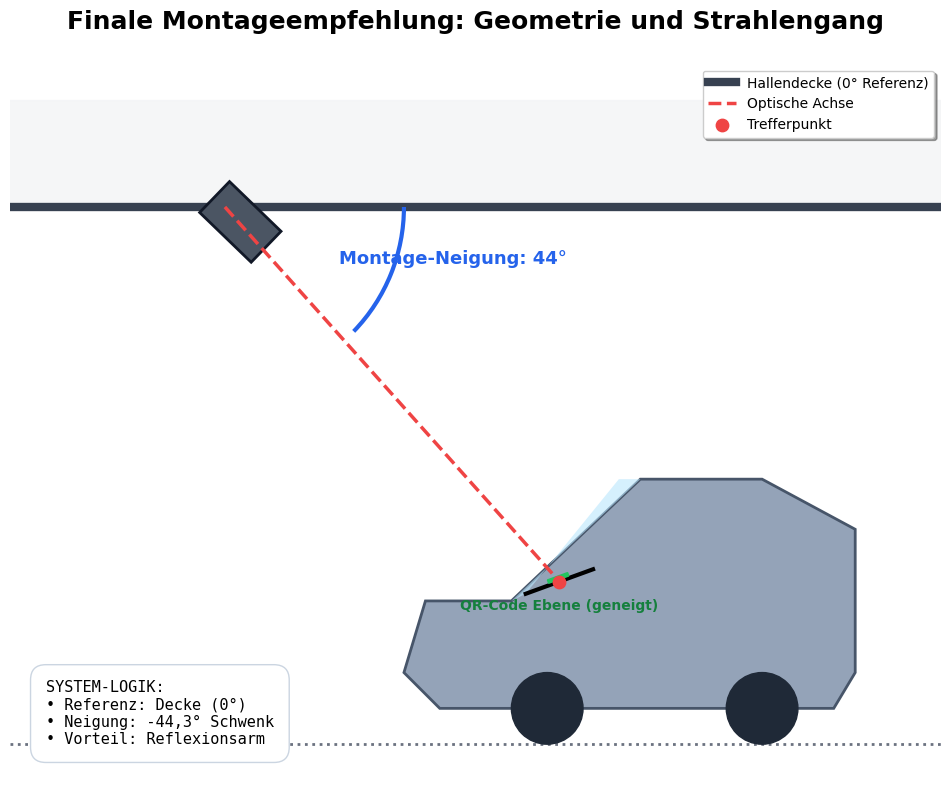

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualize_montage_v4(angle_deg=44):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Farben
    color_ceiling = '#374151'
    color_car_body = '#94a3b8'
    color_car_windows = '#bae6fd'
    color_wheels = '#1f2937'
    color_camera = '#4b5563'
    color_axis = '#ef4444'
    color_arc = '#2563eb'
    
    # --- A. HALLEN-UMGEBUNG ---
    mount_height = 8
    ax.plot([-1, 13], [mount_height, mount_height], color=color_ceiling, linewidth=6, label="Hallendecke (0° Referenz)")
    ax.fill_between([-1, 13], mount_height, 9.5, color='#f3f4f6', alpha=0.8)
    ax.axhline(0.5, color='#6b7280', linewidth=2, linestyle=':')

    # --- B. FAHRZEUG ---
    # Räder
    ax.add_patch(patches.Circle((7.5, 1.0), 0.5, color=color_wheels, zorder=4))
    ax.add_patch(patches.Circle((10.5, 1.0), 0.5, color=color_wheels, zorder=4))
    
    # Karosserie
    car_points = [[6.0, 1.0], [11.5, 1.0], [11.8, 1.5], [11.8, 3.5], 
                  [10.5, 4.2], [8.8, 4.2], [7.0, 2.5], [5.8, 2.5], [5.5, 1.5]]
    car_body = patches.Polygon(car_points, closed=True, facecolor=color_car_body, edgecolor='#475569', linewidth=2, zorder=2)
    ax.add_patch(car_body)
    
    # Fenster
    windshield_pts = [[7.0, 2.5], [8.8, 4.2], [8.5, 4.2], [7.2, 2.6]]
    ax.add_patch(patches.Polygon(windshield_pts, closed=True, facecolor=color_car_windows, alpha=0.6, zorder=3))

    # --- C. QR-CODE (GENEIGT) ---
    # Position und Neigung des Dashboards
    dash_start = np.array([7.2, 2.6])
    dash_angle = np.radians(20) # Leichte Neigung des Armaturenbretts
    dash_len = 1.0
    dash_end = dash_start + np.array([dash_len * np.cos(dash_angle), dash_len * np.sin(dash_angle)])
    
    # Dashboard-Linie
    ax.plot([dash_start[0], dash_end[0]], [dash_start[1], dash_end[1]], color='black', linewidth=3, zorder=5)
    
    # QR-Code Marker (mittig auf dem Dashboard)
    qr_center = dash_start + 0.5 * (dash_end - dash_start)
    qr_marker = patches.Rectangle((qr_center[0]-0.15, qr_center[1]-0.025), 0.3, 0.05, angle=np.degrees(dash_angle), color='#22c55e', zorder=6)
    ax.add_patch(qr_marker)
    ax.text(qr_center[0], qr_center[1]-0.4, "QR-Code Ebene (geneigt)", fontsize=10, fontweight='bold', ha='center', color='#15803d')

    # --- D. KAMERA & OPTIK ---
    pivot_x, pivot_y = 3, mount_height
    theta_rad = np.radians(angle_deg)
    
    # Kamera
    cam_w, cam_h = 1.0, 0.6
    camera = patches.Rectangle((pivot_x - 0.2, pivot_y - cam_h/2), cam_w, cam_h, linewidth=2, edgecolor='#111827', facecolor=color_camera, zorder=10)
    t = patches.transforms.Affine2D().rotate_deg_around(pivot_x, pivot_y, -angle_deg) + ax.transData
    camera.set_transform(t)
    ax.add_patch(camera)
    
    # Optische Achse (Ziel: QR-Code Zentrum)
    ax.plot([pivot_x, qr_center[0]], [pivot_y, qr_center[1]], color=color_axis, linestyle='--', linewidth=2.5, label=f"Optische Achse", zorder=11)
    # Trefferpunkt markieren
    ax.scatter(qr_center[0], qr_center[1], color=color_axis, s=80, zorder=12, label="Trefferpunkt")

    # --- E. ANNOTATIONEN ---
    # Winkelbogen
    arc_radius = 2.5
    ax.add_patch(patches.Arc((pivot_x, pivot_y), arc_radius*2, arc_radius*2, angle=0, theta1=-angle_deg, theta2=0, color=color_arc, linewidth=3, zorder=15))
    ax.text(pivot_x + 1.6, pivot_y - 0.8, f"Montage-Neigung: {angle_deg}°", fontsize=13, color=color_arc, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

    # Info-Box
    info_text = "SYSTEM-LOGIK:\n• Referenz: Decke (0°)\n• Neigung: -44,3° Schwenk\n• Vorteil: Reflexionsarm"
    ax.text(0.5, 0.5, info_text, fontsize=11, family='monospace', bbox=dict(facecolor='white', edgecolor='#cbd5e1', boxstyle='round,pad=1'), zorder=20)

    # Styling
    ax.set_aspect('equal')
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 10)
    ax.set_title("Finale Montageempfehlung: Geometrie und Strahlengang", fontsize=18, fontweight='bold', pad=25)
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_montage_v4(44)